In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

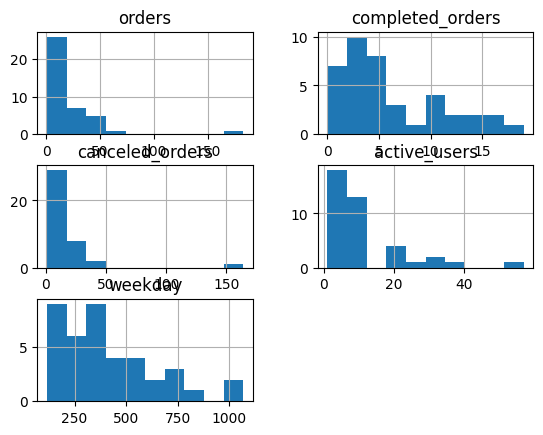

In [ ]:
df = pd.read_csv("../ML/prod_mizban.orders.csv")

newData= df.drop(columns=["date"])
newData.astype("int16")

plt.figure(figsize=(10,5))
newData.hist()
plt.show()

In [ ]:
df["total_order"] = df["completed_orders"] + df["canceled_orders"]
df["promo"]= 0
df.loc[df['active_users'] > 5 , ['promo']] =1

x = df.drop(columns=['date','orders'])
x.head(2)

In [ ]:
missing_values = df.isnull()
df.select_dtypes(int)
print(missing_values)        

In [ ]:
#  drop all rows with at least one missing value 

df.dropna(how="any")

#  drop rows with missing values in specific column

df.dropna(subset=["VersionControl"])

# replace missing values in a specific column
df["VersionControl"].fillna(
    value="None Given", inplace=True
)


df["convertedSalary"]=df["convertedSalary"].fillna(
   df["convertedSalary"].Mean()
)

#  Record where the values are not missing 
# we select this when we to transform all data of specific column to another and then drop it
df["salaryGeven"]= df['convertedSalary'].notnull()
df.drop(columns=["convertedSalary"])



# Print the count of occurrences
print(df['Gender'].value_counts())


In [ ]:
# rmeoving the comma from our column
df["my_column"]= df["my_column"].str.replace(",","")
print(df[coerced_val.isna()].head())




# Attempt to convert the column to numeric values
numeric_vals = pd.to_numeric(so_survey_df['RawSalary'], errors='coerce')

# Find the indexes of missing values
idx = numeric_vals.isna()

# Print the relevant rows
print(so_survey_df['RawSalary'][idx])


# Use method chaining
so_survey_df['RawSalary'] = so_survey_df['RawSalary']\
                              .str.replace(",","")\
                              .str.replace("$","")\
                              .str.replace("£","")\
                              .astype(float)
 
# Print the RawSalary column
print(so_survey_df['RawSalary'])




so_numeric_df[['ConvertedSalary']].boxplot()
plt.show()

In [ ]:
# scaling and 


scaler = MinMaxScaler()
scaler.fit(df["age"])
df["normalized_age"]= scaler.transform(df["age"])


df["log_convetedSalary"]= log.transform(df[['convertedSalary']])



# Import StandardScaler

from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
SS_scaler = StandardScaler()

# Fit SS_scaler to the data
SS_scaler.fit(so_numeric_df[['Age']])

# Transform the data using the fitted scaler
so_numeric_df['Age_SS'] = SS_scaler.transform(so_numeric_df[['Age']])

# Compare the origional and transformed column
print(so_numeric_df[['Age_SS', 'Age']].head())

In [ ]:
# Import PowerTransformer
from sklearn.preprocessing import PowerTransformer

# Instantiate PowerTransformer
pow_trans = PowerTransformer()

# Train the transform on the data
pow_trans.fit(so_numeric_df[['ConvertedSalary']])

# Apply the power transform to the data
so_numeric_df['ConvertedSalary_LG'] = pow_trans.transform(so_numeric_df[['ConvertedSalary']])

# Plot the data before and after the transformation
so_numeric_df[['ConvertedSalary', 'ConvertedSalary_LG']].hist()
plt.show()

In [ ]:
# outlier 

q_cutoff=df["col_name"].quantile(0.95)

mask= df["col_name"] < q_cutoff


trimed_df= df[mask]


# standard deviation detection in python


mean= df["col_name"].mean()
std= df["col_name"].std()

cutoff = std * 3

lower, upper = mean - cutoff , mean + cutoff

new_df= df[(df['col_name'] < upper) & (df['col_name'] > lower)]



# Find the 95th quantile
quantile = so_numeric_df['ConvertedSalary'].quantile(0.95)

# Trim the outliers
trimmed_df = so_numeric_df[so_numeric_df['ConvertedSalary'] < quantile]

# The original histogram
so_numeric_df[['ConvertedSalary']].hist()
plt.show()
plt.clf()

# The trimmed histogram
trimmed_df[['ConvertedSalary']].hist()
plt.show()




train_std = so_train_numeric['ConvertedSalary'].std()
train_mean = so_train_numeric['ConvertedSalary'].mean()

cut_off = train_std * 3
train_lower, train_upper = train_mean - cut_off, train_mean + cut_off

# Trim the test DataFrame
trimmed_df = so_test_numeric[(so_test_numeric['ConvertedSalary'] < train_upper) 
                             & (so_test_numeric['ConvertedSalary'] > train_lower)]

In [ ]:
# text encoding is very important


# Replace all non letter characters with a whitespace
speech_df['text_clean'] = speech_df['text'].replace('[^a-zA-Z]', ' ')

# Change to lower case
speech_df['text_clean'] = speech_df['text_clean'].str.lower()

# Print the first 5 rows of the text_clean column
print(speech_df['text_clean'].head())



# Find the length of each text
speech_df['char_cnt'] = speech_df['text_clean'].str.len()

# Count the number of words in each text
speech_df['word_cnt'] = speech_df['text_clean'].str.split().str.len()

# Find the average length of word
speech_df['avg_word_length'] = speech_df['char_cnt'] / speech_df['word_cnt'] 

# Print the first 5 rows of these columns
print(speech_df[['text_clean', 'char_cnt', 'word_cnt', 'avg_word_length']])